In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('who2009.csv')

df.shape

# Rename columns

df.rename(columns={'v9': 'life_exp', 'v22': 'infant_mortality', 'v159': 'phys_density', 'v168': 'hospital_bed', 'v174': 'health_exp_percent_GDP', 'v186': 'OOP_percent_exp', 'v192': 'health_exp_PC', 'v249': 'fertility_rate', 'v259': 'GNI_PC' }, inplace=True)

# Now that we've renamed, we can drop everything matching v\d+
df.drop(columns=df.filter(regex=r'^v\d+$').columns, inplace=True)
df.drop(columns=['regioncode', 'countrycode', 'iso3', 'subregioncode', 'subregionname'], inplace=True)

df.head()

,country,life_exp,infant_mortality,phys_density,hospital_bed,health_exp_percent_GDP,OOP_percent_exp,health_exp_PC,fertility_rate,GNI_PC,regionname
0,Afghanistan,42,165,2.0,4.0,9.2,78.5,91.0,7.1,NaN,Asia
1,Albania,72,13,12.0,30.0,6.5,94.9,381.0,2.1,6580.0,Europe
2,Algeria,71,33,11.0,17.0,4.2,94.6,315.0,2.4,7640.0,Africa
3,Andorra,81,3,36.0,32.0,7.4,73.4,2980.0,1.3,NaN,Europe
4,Angola,53,116,1.0,8.0,2.6,100.0,115.0,6.5,4400.0,Africa


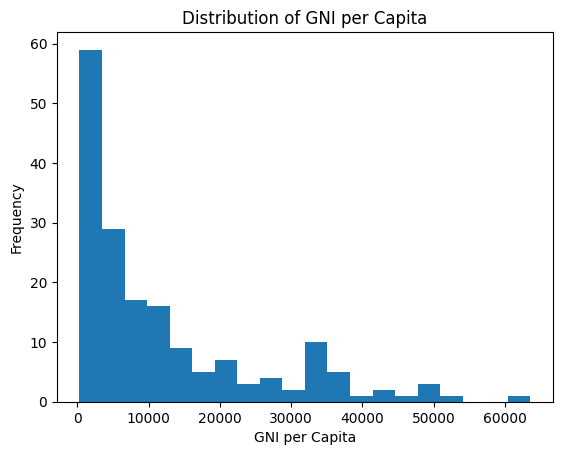

In [2]:
# Plot GNI_PC distribution

plt.hist(df['GNI_PC'], bins=20)
plt.xlabel('GNI per Capita')
plt.ylabel('Frequency')
plt.title('Distribution of GNI per Capita')
plt.show()

# Plot the distribution of the GNI PC variable. Given the shape of this distribution what methods would you apply to deal with those missing values?

The distribution is right-skewed with a long tail on the right side. This suggests that there are many countries with low GNI per capita and fewer with high GNI per capita.
To deal with missing values in such a skewed distribution, one could:
1. Use median imputation instead of mean imputation to avoid skewing the data.
2. Use more sophisticated imputation methods like KNN imputation or regression imputation.
3. Consider using log transformation to make the distribution more symmetric before imputation.

In [3]:
df_europe = df[df['regionname'] == 'Europe']

def one_sample_t_test(data: pd.Series, popmean: float) -> tuple[float, float]:
    '''Perform a one-sample t-test on the given data against the specified population mean.
    Parameters:
    data (pd.Series): The sample data to test.
    popmean (float): The population mean to compare against.
    Returns:
    tuple[float, float]: A tuple containing the t-statistic and the p-value of the test.
    '''
    data_clean = data.dropna()
    n = len(data_clean)

    if n < 2:
        t_statistic, p_value = float("nan"), float("nan")
    else:
        sample_mean = data_clean.mean()
        sample_std = data_clean.std(ddof=1)

        if sample_std == 0:
            t_statistic, p_value = float("nan"), float("nan")
        else:
            t_statistic = (sample_mean - popmean) / (sample_std / (n ** 0.5))
            p_value = 2 * stats.t.sf(abs(t_statistic), df=n - 1)
    return t_statistic, p_value # type: ignore

life_exp_70 = one_sample_t_test(df_europe['life_exp'], 70)
life_exp_76 = one_sample_t_test(df_europe['life_exp'], 76)

val_life_exp_70 = stats.ttest_1samp(df_europe['life_exp'].dropna(), 70)
val_life_exp_76 = stats.ttest_1samp(df_europe['life_exp'].dropna(), 76)

print(f"Custom function - Life Expectancy vs 70: t-statistic = {life_exp_70[0]:.4f}, p-value = {life_exp_70[1]:.4f}")
print(f"Custom function - Life Expectancy vs 76: t-statistic = {life_exp_76[0]:.4f}, p-value = {life_exp_76[1]:.4f}")
print(f"scipy function - Life Expectancy vs 70: t-statistic = {val_life_exp_70.statistic:.4f}, p-value = {val_life_exp_70.pvalue:.4f}") # type: ignore
print(f"scipy function - Life Expectancy vs 76: t-statistic = {val_life_exp_76.statistic:.4f}, p-value = {val_life_exp_76.pvalue:.4f}") # type: ignore

Custom function - Life Expectancy vs 70: t-statistic = 9.9380, p-value = 0.0000
Custom function - Life Expectancy vs 76: t-statistic = 1.1814, p-value = 0.2442
scipy function - Life Expectancy vs 70: t-statistic = 9.9380, p-value = 0.0000
scipy function - Life Expectancy vs 76: t-statistic = 1.1814, p-value = 0.2442


### One-Sample t-test Writeup

**(a) How do you choose the fixed number $M$ in this test?**

Choose $M$ based on the scientific or practical benchmark you want to test against (for example, a policy target, historical norm, or known reference value). In this lab, $M=70$ and $M=76$ are candidate benchmark life expectancies.

**(b) What are the null and alternative hypotheses for the one-sample t-test conducted here?**

For each benchmark value $M$:
- $H_0: \mu = M$ (the population mean life expectancy equals $M$)
- $H_A: \mu \neq M$ (the population mean life expectancy is different from $M$)

**(c) Explain the equation for the p-value. What is it doing?**

The p-value is computed as $2\,P(T_{df}\ge |t|)$, where $T_{df}$ follows a t-distribution with $df=n-1$. This calculates the probability (under $H_0$) of seeing a test statistic at least as extreme as the observed one in either direction, which is why the factor of 2 appears for a two-sided test.

**(d) Is life expectancy in Europe significantly different from 70 years or 76 years? How do you know?**

Using your outputs:
- vs 70: $t=9.9380$, $p\approx 0.0000$ $\Rightarrow$ reject $H_0$ at common levels (e.g., 0.05). Europe’s mean life expectancy is significantly different from 70.
- vs 76: $t=1.1814$, $p=0.2442$ $\Rightarrow$ fail to reject $H_0$. There is not enough evidence that Europe’s mean life expectancy differs from 76.

**(e) Did your function produce the same results as the built-in version?**

Yes. The custom function and `scipy.stats.ttest_1samp` return matching t-statistics and p-values (up to rounding).

In [4]:
df_asia = df[df['regionname'] == 'Asia']

def two_sample_t_test(data1: pd.Series, data2: pd.Series) -> tuple[float, float]:
    '''Perform a two-sample t-test on the given data samples.
    Parameters:
    data1 (pd.Series): The first sample data.
    data2 (pd.Series): The second sample data.
    Returns:
    tuple[float, float]: A tuple containing the t-statistic and the p-value of the test.
    '''
    data1_clean = data1.dropna()
    data2_clean = data2.dropna()

    n1 = len(data1_clean)
    n2 = len(data2_clean)

    if n1 < 2 or n2 < 2:
        t_statistic, p_value = float("nan"), float("nan")
    else:
        mean1 = data1_clean.mean()
        mean2 = data2_clean.mean()
        std1 = data1_clean.std(ddof=1)
        std2 = data2_clean.std(ddof=1)

        if std1 == 0 or std2 == 0:
            t_statistic, p_value = float("nan"), float("nan")
        else:
            pooled_std = (((n1 - 1) * std1 ** 2 + (n2 - 1) * std2 ** 2) / (n1 + n2 - 2)) ** 0.5
            t_statistic = (mean1 - mean2) / (pooled_std * ((1/n1 + 1/n2) ** 0.5))
            p_value = 2 * stats.t.sf(abs(t_statistic), df=n1 + n2 - 2)
    return t_statistic, p_value # type: ignore

life_exp_comp = two_sample_t_test(df_europe['life_exp'], df_asia['life_exp'])

val_life_exp_comp = stats.ttest_ind(df_europe['life_exp'].dropna(), df_asia['life_exp'].dropna(), equal_var=True)

print(f"Custom function - Life Expectancy Comparison: t-statistic = {life_exp_comp[0]:.4f}, p-value = {life_exp_comp[1]:.4f}")
print(f"scipy function - Life Expectancy Comparison: t-statistic = {val_life_exp_comp.statistic:.4f}, p-value = {val_life_exp_comp.pvalue:.4f}") # type: ignore

Custom function - Life Expectancy Comparison: t-statistic = 5.7265, p-value = 0.0000
scipy function - Life Expectancy Comparison: t-statistic = 5.7265, p-value = 0.0000


### Two-Sample t-test Writeup

**(a) What are the null and alternative hypotheses for the two-sample t-test conducted here?**

Let $\mu_E$ be mean life expectancy in Europe and $\mu_A$ be mean life expectancy in Asia.
- $H_0: \mu_E = \mu_A$
- $H_A: \mu_E \neq \mu_A$

**(b) Is life expectancy in Europe significantly different from life expectancy in Asia? How do you know?**

From your results: $t=5.7265$ and $p\approx 0.0000$. Since the p-value is far below 0.05, reject $H_0$. There is strong statistical evidence that mean life expectancy differs between Europe and Asia.

**(c) Did your function produce the same results as the built-in version?**

Yes. The custom two-sample t-test matches `scipy.stats.ttest_ind` (equal variances) for both the t-statistic and p-value (up to rounding).

In [8]:
def pearson_correlation_test(var1: pd.Series, var2: pd.Series) -> tuple[float, float, float]:
    """Compute Pearson correlation r, test statistic t, and two-sided p-value.

    Returns:
        tuple[float, float, float]: (r, t_statistic, p_value)
    """
    paired = pd.concat([var1, var2], axis=1).dropna()
    x = paired.iloc[:, 0]
    y = paired.iloc[:, 1]

    n = len(paired)
    if n < 3:
        return float("nan"), float("nan"), float("nan")

    x_mean = x.mean()
    y_mean = y.mean()

    x_centered = x - x_mean
    y_centered = y - y_mean

    numerator = (x_centered * y_centered).sum()
    denominator = ((x_centered ** 2).sum() ** 0.5) * ((y_centered ** 2).sum() ** 0.5)

    if denominator == 0:
        return float("nan"), float("nan"), float("nan")

    r = numerator / denominator

    if abs(r) >= 1:
        t_statistic = float("inf") if r > 0 else float("-inf")
        p_value = 0.0
    else:
        t_statistic = r * ((n - 2) / (1 - r ** 2)) ** 0.5
        p_value = 2 * stats.t.sf(abs(t_statistic), df=n - 2)

    return float(r), float(t_statistic), float(p_value)


paired_all = df[['life_exp', 'infant_mortality']].dropna()
r_custom, t_custom, p_custom = pearson_correlation_test(paired_all['life_exp'], paired_all['infant_mortality'])
linreg_result = stats.linregress(paired_all['life_exp'], paired_all['infant_mortality'])

n = len(paired_all)
t_from_linreg_r = linreg_result.rvalue * ((n - 2) / (1 - linreg_result.rvalue ** 2)) ** 0.5

print(f"Custom Pearson test -> r = {r_custom:.6f}, t = {t_custom:.6f}, p-value = {p_custom:.6e}")
print(
    f"linregress          -> r = {linreg_result.rvalue:.6f}, t = {t_from_linreg_r:.6f}, "
    f"p-value = {linreg_result.pvalue:.6e}"
)

Custom Pearson test -> r = -0.925537, t = -33.780408, p-value = 1.733833e-82
linregress          -> r = -0.925537, t = -33.780408, p-value = 1.733833e-82


### 4) Pearson Correlation Test Writeup

**(a) Null and alternative hypotheses**

- **Null hypothesis ($H_0$):** There is no linear correlation between life expectancy and infant mortality in the population, i.e., $\rho = 0$.
- **Alternative hypothesis ($H_A$):** There is a linear correlation between life expectancy and infant mortality, i.e., $\rho \neq 0$.

**(b) Compare custom function vs `linregress`**

- The custom function computes the same core quantities: Pearson correlation coefficient ($r$), a $t$ statistic based on $r$, and a two-sided p-value.
- In `linregress`, the returned `rvalue` is the same Pearson correlation coefficient and `pvalue` corresponds to testing whether slope/correlation is zero.
- In this dataset, both methods match exactly (up to floating-point precision):
  - $r = -0.925537$
  - $t = -33.780408$
  - $p = 1.733833 \times 10^{-82}$

**(c) Relationship between life expectancy and infant mortality**

- There is a **strong negative** linear relationship between life expectancy and infant mortality ($r \approx -0.93$).
- Because the p-value is extremely small ($p \ll 0.05$), we reject $H_0$ and conclude the relationship is statistically significant.
- Interpretation: countries with higher infant mortality tend to have lower life expectancy.

### 5) Additional Statistical Tests (Kruskal-Wallis and $\chi^2$ Independence)

**(a) Variable types + assumptions**

- **Kruskal-Wallis test:**
  - Variable types: one **categorical** grouping variable (2+ independent groups) and one **continuous/ordinal** response variable.
  - Key assumptions: independent observations, groups are independent, response measured at least ordinal scale, and group distributions have similar shape if interpreting differences as medians.

- **$\chi^2$ test for independence:**
  - Variable types: two **categorical** variables summarized in a contingency table.
  - Key assumptions: independent observations, counts (not percentages) are used, and expected cell counts are sufficiently large (common rule: most expected counts $\ge 5$).

**(b) General null/alternative hypotheses**

- **Kruskal-Wallis:**
  - $H_0$: all groups come from the same distribution (often phrased as equal medians/distributions across groups).
  - $H_A$: at least one group differs from the others.

- **$\chi^2$ independence:**
  - $H_0$: the two categorical variables are independent (no association).
  - $H_A$: the variables are not independent (there is an association).

**(c) Meaning of significance vs non-significance**

- If a test is **statistically significant** (small p-value), data provide evidence against $H_0$.
  - Kruskal-Wallis: at least one group differs.
  - $\chi^2$: the categorical variables are associated.
- If a test is **not significant**, there is not enough evidence to reject $H_0$.
  - This does **not** prove groups/variables are exactly identical or independent; it means the sample did not show strong enough evidence of a difference/association.